# 04. Advanced Classification Models

Notebook này triển khai đầy đủ phần bonus cho **CSC14005 - Project 1, Part 2: Classification** theo đúng cấu trúc học thuật:

- Mỗi phương pháp đều có **markdown lý thuyết bằng tiếng Việt**
- Có **một code cell cài đặt từ đầu** cho phần lõi
- Có **markdown phân tích kết quả** ngay sau phần chạy thực nghiệm

Phạm vi dữ liệu được chia như sau:

- **Probit** và **Laplace Approximation**: dùng lát cắt nhị phân 2 chiều từ bộ dữ liệu **Covertype** để có thể trực quan hóa decision boundary.
- **Kernel Logistic Regression**: dùng dữ liệu **XOR-like** để minh họa rõ ràng tính không tách tuyến tính, đúng theo yêu cầu bonus.
- **Gaussian Naive Bayes vs LDA**: dùng dữ liệu **Covertype đa lớp** để đánh giá trên dữ liệu thực.

Toàn bộ các mô hình lõi trong notebook đều được cài đặt bằng `numpy`. `scikit-learn` chỉ xuất hiện ở các block **validation** để kiểm tra độ hợp lý của kết quả.

In [1]:
import random
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as SklearnLDA
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, f1_score, log_loss, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB as SklearnGaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.float_format", lambda value: f"{value:0.4f}")

project_root = Path.cwd().parent.parent.parent
data_path = project_root / "data" / "raw" / "classification" / "covtype.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Không tìm thấy dữ liệu tại: {data_path}")

df_covtype = pd.read_csv(data_path)

continuous_cols = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]
wilderness_cols = [f"Wilderness_Area{i}" for i in range(1, 5)]
soil_cols = [f"Soil_Type{i}" for i in range(1, 41)]

df_covtype["Euclidean_Distance_To_Hydrology"] = np.sqrt(
    df_covtype["Horizontal_Distance_To_Hydrology"] ** 2
    + df_covtype["Vertical_Distance_To_Hydrology"] ** 2
)
df_covtype["Distance_To_Amenities"] = (
    df_covtype["Horizontal_Distance_To_Roadways"]
    + df_covtype["Horizontal_Distance_To_Fire_Points"]
)

engineered_cols = ["Euclidean_Distance_To_Hydrology", "Distance_To_Amenities"]
gaussian_feature_cols = continuous_cols + engineered_cols
mixed_feature_cols = gaussian_feature_cols + wilderness_cols + soil_cols

print(f"Kích thước dữ liệu Covertype: {df_covtype.shape}")
print("Số lớp:", df_covtype["Cover_Type"].nunique())
print("Phân bố lớp:")
print(df_covtype["Cover_Type"].value_counts().sort_index().to_string())


def sigmoid(z):
    z = np.clip(z, -40.0, 40.0)
    return 1.0 / (1.0 + np.exp(-z))


def normal_pdf(z):
    return np.exp(-0.5 * z ** 2) / np.sqrt(2.0 * np.pi)


def normal_cdf(z):
    x = np.abs(z) / np.sqrt(2.0)
    t = 1.0 / (1.0 + 0.3275911 * x)
    a1, a2, a3, a4, a5 = 0.254829592, -0.284496736, 1.421413741, -1.453152027, 1.061405429
    erf_approx = 1.0 - (((((a5 * t + a4) * t) + a3) * t + a2) * t + a1) * t * np.exp(-x * x)
    return 0.5 * (1.0 + np.sign(z) * erf_approx)


def logsumexp(values, axis=1, keepdims=True):
    max_values = np.max(values, axis=axis, keepdims=True)
    stabilized = np.exp(values - max_values)
    total = np.sum(stabilized, axis=axis, keepdims=True)
    result = max_values + np.log(total)
    if keepdims:
        return result
    return np.squeeze(result, axis=axis)


def add_bias(X):
    return np.column_stack([np.ones(X.shape[0]), X])


def standardize_train_test(X_train, X_test):
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True)
    std = np.where(std < 1e-10, 1.0, std)
    return (X_train - mean) / std, (X_test - mean) / std, mean, std


def balanced_pair_sample(df, class_pair, n_per_class, seed):
    parts = []
    for class_id in class_pair:
        class_df = df[df["Cover_Type"] == class_id]
        take = min(n_per_class, len(class_df))
        parts.append(class_df.sample(n=take, random_state=seed))
    return pd.concat(parts, axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)


def stratified_dataframe_sample(df, target_col, total_size, seed):
    if total_size >= len(df):
        return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    proportions = df[target_col].value_counts(normalize=True).sort_index()
    raw_counts = proportions * total_size
    floor_counts = np.floor(raw_counts).astype(int).clip(lower=1)
    remainder = total_size - int(floor_counts.sum())
    if remainder > 0:
        order = np.argsort(-(raw_counts - floor_counts))
        for idx in order[:remainder]:
            floor_counts.iloc[idx] += 1
    elif remainder < 0:
        order = np.argsort(raw_counts - floor_counts)
        for idx in order[: abs(remainder)]:
            if floor_counts.iloc[idx] > 1:
                floor_counts.iloc[idx] -= 1
    sampled_parts = []
    for class_id, count in floor_counts.items():
        class_df = df[df[target_col] == class_id]
        take = min(int(count), len(class_df))
        sampled_parts.append(class_df.sample(n=take, random_state=seed))
    return pd.concat(sampled_parts, axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)


def stratified_index_sample(y, total_size, seed):
    rng_local = np.random.default_rng(seed)
    y = np.asarray(y)
    classes, counts = np.unique(y, return_counts=True)
    if total_size >= len(y):
        indices = np.arange(len(y))
        rng_local.shuffle(indices)
        return indices
    proportions = counts / counts.sum()
    target_counts = np.floor(proportions * total_size).astype(int)
    target_counts = np.maximum(target_counts, 1)
    remainder = total_size - int(target_counts.sum())
    if remainder > 0:
        order = np.argsort(-(proportions * total_size - target_counts))
        for idx in order[:remainder]:
            target_counts[idx] += 1
    elif remainder < 0:
        order = np.argsort(proportions * total_size - target_counts)
        for idx in order[: abs(remainder)]:
            if target_counts[idx] > 1:
                target_counts[idx] -= 1
    sampled = []
    for class_id, target_count in zip(classes, target_counts):
        class_idx = np.flatnonzero(y == class_id)
        take = min(int(target_count), len(class_idx))
        sampled.append(rng_local.choice(class_idx, size=take, replace=False))
    indices = np.concatenate(sampled)
    rng_local.shuffle(indices)
    return indices


def inject_label_noise(y, noise_rate, seed):
    rng_local = np.random.default_rng(seed)
    y_noisy = y.copy()
    n_flip = int(len(y_noisy) * noise_rate)
    flip_idx = rng_local.choice(len(y_noisy), size=n_flip, replace=False)
    y_noisy[flip_idx] = 1 - y_noisy[flip_idx]
    return y_noisy


def fisher_two_feature_names(X_df, y_binary):
    class0 = X_df[y_binary == 0]
    class1 = X_df[y_binary == 1]
    mean0 = class0.mean(axis=0).to_numpy()
    mean1 = class1.mean(axis=0).to_numpy()
    var0 = class0.var(axis=0, ddof=1).to_numpy()
    var1 = class1.var(axis=0, ddof=1).to_numpy()
    fisher_score = (mean1 - mean0) ** 2 / (var0 + var1 + 1e-12)
    top_idx = np.argsort(fisher_score)[::-1][:2]
    return list(X_df.columns[top_idx]), fisher_score


def binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    precision, recall, f1_value, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision,
        "Recall": recall,
        "F1": f1_value,
        "LogLoss": log_loss(y_true, y_prob, labels=[0, 1]),
        "Brier": brier_score_loss(y_true, y_prob),
    }


def multiclass_metrics(y_true, y_pred):
    precision, recall, f1_value, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "MacroPrecision": precision,
        "MacroRecall": recall,
        "MacroF1": f1_value,
    }


def make_meshgrid(X, margin=0.5, n_points=220):
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, n_points), np.linspace(y_min, y_max, n_points))
    return xx, yy


def plot_binary_boundary(ax, model, X, y, feature_names, title, grid_resolution=220):
    xx, yy = make_meshgrid(X, margin=0.5, n_points=grid_resolution)
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    probs = model.predict_proba(grid).reshape(xx.shape)
    contour = ax.contourf(xx, yy, probs, levels=np.linspace(0.0, 1.0, 15), cmap="coolwarm", alpha=0.65)
    ax.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="#1f77b4", s=18, alpha=0.65, label="Class 0", edgecolors="none")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="#d62728", s=18, alpha=0.65, label="Class 1", edgecolors="none")
    ax.set_title(title)
    ax.set_xlabel(f"{feature_names[0]} (z-score)")
    ax.set_ylabel(f"{feature_names[1]} (z-score)")
    ax.legend(loc="upper right")
    return contour


class BinaryLogisticGD:
    def __init__(self, learning_rate=0.1, max_iter=3000, lambda_reg=1e-2, tol=1e-7):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.lambda_reg = lambda_reg
        self.tol = tol
        self.weights_ = None
        self.history_ = []

    def _loss(self, X_bias, y):
        probs = np.clip(sigmoid(X_bias @ self.weights_), 1e-10, 1.0 - 1e-10)
        penalty = 0.5 * self.lambda_reg * np.sum(self.weights_[1:] ** 2)
        return -np.mean(y * np.log(probs) + (1.0 - y) * np.log(1.0 - probs)) + penalty

    def fit(self, X, y):
        X_bias = add_bias(X)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X_bias.shape
        self.weights_ = np.zeros(n_features, dtype=float)
        for iteration in range(self.max_iter):
            probs = sigmoid(X_bias @ self.weights_)
            gradient = (X_bias.T @ (probs - y)) / n_samples
            gradient[1:] += self.lambda_reg * self.weights_[1:]
            updated_weights = self.weights_ - self.learning_rate * gradient
            if np.linalg.norm(updated_weights - self.weights_) < self.tol:
                self.weights_ = updated_weights
                break
            self.weights_ = updated_weights
            if iteration % 50 == 0:
                self.history_.append(self._loss(X_bias, y))
        return self

    def decision_function(self, X):
        return add_bias(X) @ self.weights_

    def predict_proba(self, X):
        return sigmoid(self.decision_function(X))

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


def make_xor_dataset(n_samples=400, noise=0.20, seed=SEED):
    rng_local = np.random.default_rng(seed)
    X = rng_local.uniform(-2.0, 2.0, size=(n_samples, 2))
    y = ((X[:, 0] * X[:, 1]) > 0.0).astype(int)
    X = X + rng_local.normal(scale=noise, size=X.shape)
    return X, y

Kích thước dữ liệu Covertype: (581012, 57)
Số lớp: 7
Phân bố lớp:
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510


## 1. Probit Model

### Cơ sở lý thuyết

Probit model là một **Generalized Linear Model** cho bài toán nhị phân, trong đó xác suất lớp dương được mô hình hóa bằng **Gaussian CDF**:

$$
p(y = 1 \mid \mathbf{x}) = \Phi(z), \qquad z = \mathbf{w}^{\top}\tilde{\mathbf{x}}
$$

với $\tilde{\mathbf{x}} = [1, \mathbf{x}^{\top}]^{\top}$ là vector đặc trưng có thêm bias, $\Phi(\cdot)$ là hàm phân phối tích lũy của chuẩn tắc, còn mật độ chuẩn tắc là

$$
\phi(z) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{z^2}{2}\right).
$$

Hàm log-likelihood cho nhãn nhị phân $y_n \in \{0,1\}$ là

$$
\mathcal{L}(\mathbf{w}) =
\sum_{n=1}^{N}
\left[
y_n \log \Phi(z_n)
+ (1-y_n)\log\left(1-\Phi(z_n)\right)
\right]
- \frac{\lambda}{2}\|\mathbf{w}_{1:}\|_2^2.
$$

Suy ra gradient theo từng điểm:

$$
\frac{\partial (-\mathcal{L})}{\partial z_n}
=
-y_n \frac{\phi(z_n)}{\Phi(z_n)}
+ (1-y_n)\frac{\phi(z_n)}{1-\Phi(z_n)}.
$$

### So sánh với Logistic Regression

Logistic Regression dùng liên kết sigmoid:

$$
p(y = 1 \mid \mathbf{x}) = \sigma(z) = \frac{1}{1 + e^{-z}},
$$

trong khi Probit dùng $\Phi(z)$. Hai mô hình thường cho decision boundary khá giống nhau, nhưng:

- **Logistic** có đuôi dày hơn một chút nên xác suất có thể tiến về 0 hoặc 1 nhanh hơn.
- **Probit** có nguồn gốc tự nhiên từ giả thiết latent Gaussian, nên xác suất thường mượt và bớt cực đoan hơn ở vùng biên.

### Ý tưởng cài đặt

- Dùng **lát cắt nhị phân 2 chiều** từ Covertype để dễ trực quan hóa.
- Cài đặt **Logistic Regression** và **Probit** đều bằng **Gradient Descent** từ đầu.
- So sánh:
  - decision boundary,
  - calibration / output probabilities,
  - độ bền khi **tiêm noisy labels** vào tập train.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_30160\312938415.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


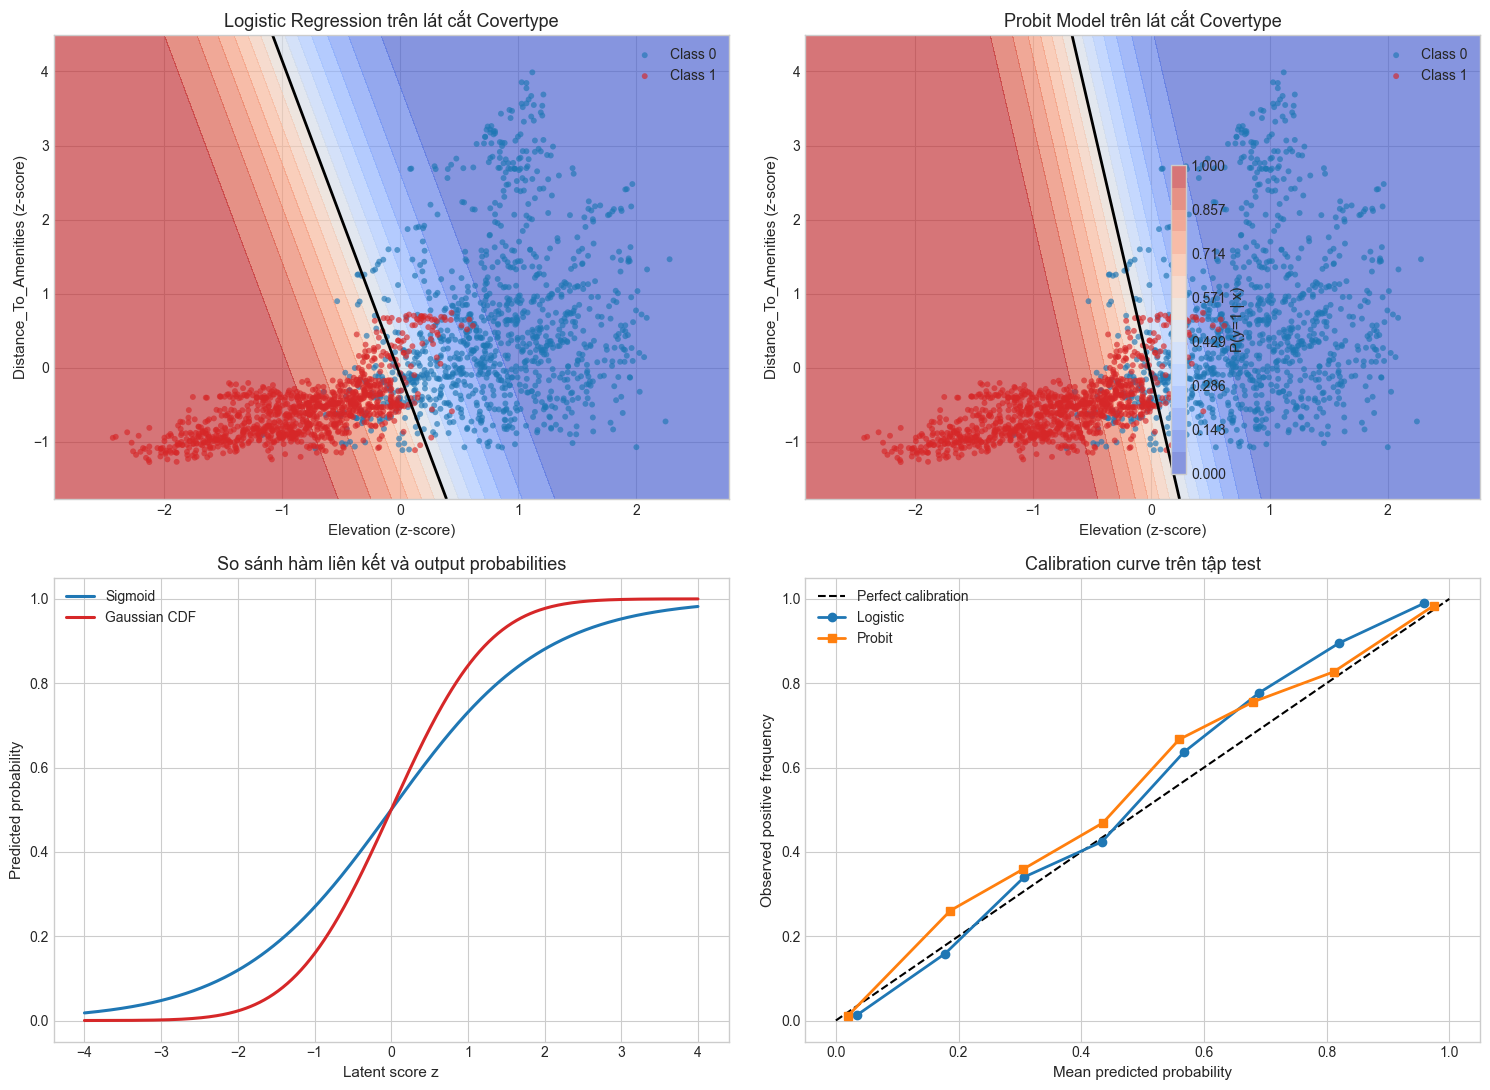

Hai đặc trưng được chọn theo Fisher score: ['Elevation', 'Distance_To_Amenities']

Bảng metric trên dữ liệu sạch:


,Accuracy,Precision,Recall,F1,LogLoss,Brier
Logistic (scratch),0.9111,0.9186,0.9022,0.9103,0.2220,0.0661
Probit (scratch),0.9100,0.9184,0.9000,0.9091,0.2119,0.0646



Bảng robustness khi tiêm noisy labels với noise_rate = 15%:


,Accuracy,Precision,Recall,F1,LogLoss,Brier
Logistic - clean train,0.9111,0.9186,0.9022,0.9103,0.2220,0.0661
Logistic - noisy train,0.9100,0.9165,0.9022,0.9093,0.3292,0.0916
Probit - clean train,0.9100,0.9184,0.9000,0.9091,0.2119,0.0646
Probit - noisy train,0.9100,0.9146,0.9044,0.9095,0.3289,0.0920



Validation với sklearn LogisticRegression:


,Accuracy,Precision,Recall,F1,LogLoss,Brier,MeanAbsProbDiff_vs_Custom
Custom Logistic,0.9111,0.9186,0.9022,0.9103,0.2220,0.0661,0.0000
Sklearn Logistic,0.9089,0.9182,0.8978,0.9079,0.2129,0.0657,0.0474


In [2]:
class ProbitGD:
    def __init__(self, learning_rate=0.05, max_iter=4000, lambda_reg=1e-2, tol=1e-7):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.lambda_reg = lambda_reg
        self.tol = tol
        self.weights_ = None
        self.history_ = []

    def _loss(self, X_bias, y):
        probs = np.clip(normal_cdf(X_bias @ self.weights_), 1e-10, 1.0 - 1e-10)
        penalty = 0.5 * self.lambda_reg * np.sum(self.weights_[1:] ** 2)
        return -np.mean(y * np.log(probs) + (1.0 - y) * np.log(1.0 - probs)) + penalty

    def fit(self, X, y):
        X_bias = add_bias(X)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X_bias.shape
        self.weights_ = np.zeros(n_features, dtype=float)
        for iteration in range(self.max_iter):
            linear_response = X_bias @ self.weights_
            cdf_values = np.clip(normal_cdf(linear_response), 1e-8, 1.0 - 1e-8)
            pdf_values = normal_pdf(linear_response)
            grad_z = -y * pdf_values / cdf_values + (1.0 - y) * pdf_values / (1.0 - cdf_values)
            gradient = (X_bias.T @ grad_z) / n_samples
            gradient[1:] += self.lambda_reg * self.weights_[1:]
            updated_weights = self.weights_ - self.learning_rate * gradient
            if np.linalg.norm(updated_weights - self.weights_) < self.tol:
                self.weights_ = updated_weights
                break
            self.weights_ = updated_weights
            if iteration % 50 == 0:
                self.history_.append(self._loss(X_bias, y))
        return self

    def decision_function(self, X):
        return add_bias(X) @ self.weights_

    def predict_proba(self, X):
        return normal_cdf(self.decision_function(X))

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


probit_pair = (2, 3)
binary_df = balanced_pair_sample(df_covtype, class_pair=probit_pair, n_per_class=1500, seed=SEED)
binary_y_full = (binary_df["Cover_Type"].to_numpy() == probit_pair[1]).astype(int)
selected_binary_features, _ = fisher_two_feature_names(binary_df[gaussian_feature_cols], binary_y_full)

X_binary = binary_df[selected_binary_features].to_numpy()
y_binary = binary_y_full.copy()
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary, y_binary, test_size=0.30, stratify=y_binary, random_state=SEED
)
X_train_bin, X_test_bin, binary_mean, binary_std = standardize_train_test(X_train_bin, X_test_bin)

logistic_model = BinaryLogisticGD(learning_rate=0.10, max_iter=3000, lambda_reg=1e-2).fit(X_train_bin, y_train_bin)
probit_model = ProbitGD(learning_rate=0.05, max_iter=4000, lambda_reg=1e-2).fit(X_train_bin, y_train_bin)

logistic_probs = logistic_model.predict_proba(X_test_bin)
probit_probs = probit_model.predict_proba(X_test_bin)

probit_clean_metrics = pd.DataFrame(
    {
        "Logistic (scratch)": binary_metrics(y_test_bin, logistic_probs),
        "Probit (scratch)": binary_metrics(y_test_bin, probit_probs),
    }
).T

noise_rate = 0.15
y_train_noisy = inject_label_noise(y_train_bin, noise_rate=noise_rate, seed=SEED)
logistic_noisy_model = BinaryLogisticGD(learning_rate=0.10, max_iter=3000, lambda_reg=1e-2).fit(X_train_bin, y_train_noisy)
probit_noisy_model = ProbitGD(learning_rate=0.05, max_iter=4000, lambda_reg=1e-2).fit(X_train_bin, y_train_noisy)
logistic_noisy_probs = logistic_noisy_model.predict_proba(X_test_bin)
probit_noisy_probs = probit_noisy_model.predict_proba(X_test_bin)

probit_noise_metrics = pd.DataFrame(
    {
        "Logistic - clean train": binary_metrics(y_test_bin, logistic_probs),
        "Logistic - noisy train": binary_metrics(y_test_bin, logistic_noisy_probs),
        "Probit - clean train": binary_metrics(y_test_bin, probit_probs),
        "Probit - noisy train": binary_metrics(y_test_bin, probit_noisy_probs),
    }
).T

sklearn_logistic = SklearnLogisticRegression(max_iter=2000, solver="lbfgs", C=100.0)
sklearn_logistic.fit(X_train_bin, y_train_bin)
sklearn_logistic_probs = sklearn_logistic.predict_proba(X_test_bin)[:, 1]

validation_table_probit = pd.DataFrame(
    {
        "Custom Logistic": binary_metrics(y_test_bin, logistic_probs),
        "Sklearn Logistic": binary_metrics(y_test_bin, sklearn_logistic_probs),
    }
).T
validation_table_probit["MeanAbsProbDiff_vs_Custom"] = [0.0, np.mean(np.abs(sklearn_logistic_probs - logistic_probs))]

z_axis = np.linspace(-4.0, 4.0, 400)
logistic_link = sigmoid(z_axis)
probit_link = normal_cdf(z_axis)
calibration_log_true, calibration_log_pred = calibration_curve(y_test_bin, logistic_probs, n_bins=8)
calibration_probit_true, calibration_probit_pred = calibration_curve(y_test_bin, probit_probs, n_bins=8)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
contour_0 = plot_binary_boundary(axes[0, 0], logistic_model, X_train_bin, y_train_bin, selected_binary_features, "Logistic Regression trên lát cắt Covertype")
plot_binary_boundary(axes[0, 1], probit_model, X_train_bin, y_train_bin, selected_binary_features, "Probit Model trên lát cắt Covertype")
axes[1, 0].plot(z_axis, logistic_link, label="Sigmoid", linewidth=2.2, color="#1f77b4")
axes[1, 0].plot(z_axis, probit_link, label="Gaussian CDF", linewidth=2.2, color="#d62728")
axes[1, 0].set_title("So sánh hàm liên kết và output probabilities")
axes[1, 0].set_xlabel("Latent score z")
axes[1, 0].set_ylabel("Predicted probability")
axes[1, 0].legend()
axes[1, 1].plot([0, 1], [0, 1], linestyle="--", color="black", label="Perfect calibration")
axes[1, 1].plot(calibration_log_pred, calibration_log_true, marker="o", linewidth=2, label="Logistic")
axes[1, 1].plot(calibration_probit_pred, calibration_probit_true, marker="s", linewidth=2, label="Probit")
axes[1, 1].set_title("Calibration curve trên tập test")
axes[1, 1].set_xlabel("Mean predicted probability")
axes[1, 1].set_ylabel("Observed positive frequency")
axes[1, 1].legend()
fig.colorbar(contour_0, ax=axes[0, :], shrink=0.8, label="P(y=1 | x)")
plt.tight_layout()
plt.show()

print("Hai đặc trưng được chọn theo Fisher score:", selected_binary_features)
print("\nBảng metric trên dữ liệu sạch:")
display(probit_clean_metrics.round(4))
print(f"\nBảng robustness khi tiêm noisy labels với noise_rate = {noise_rate:.0%}:")
display(probit_noise_metrics.round(4))
print("\nValidation với sklearn LogisticRegression:")
display(validation_table_probit.round(4))

probit_summary = {
    "selected_features": selected_binary_features,
    "clean_metrics": probit_clean_metrics,
    "noise_metrics": probit_noise_metrics,
    "validation_metrics": validation_table_probit,
    "mean_probability_gap": float(np.mean(np.abs(logistic_probs - probit_probs))),
}

### Phân tích kết quả

Từ các bảng metric và đồ thị phía trên có thể rút ra ba ý chính:

1. **Decision boundary của Probit và Logistic gần nhau** vì cả hai đều là mô hình tuyến tính trong không gian đặc trưng đã chuẩn hóa. Khác biệt chủ yếu nằm ở cách chuyển latent score sang xác suất.
2. **Output probabilities của Probit thường mềm hơn** ở vùng cận biên. Điều này thể hiện trực tiếp qua đồ thị $\sigma(z)$ so với $\Phi(z)$ và qua calibration curve trên tập test.
3. **Robustness trước noisy labels cần nhìn bằng nhiều metric**. Accuracy/F1 có thể rất gần nhau, nhưng Brier score và LogLoss cho biết mô hình nào giữ được mức độ tự tin hợp lý hơn khi nhãn huấn luyện bị nhiễu.

So với baseline Logistic Regression trong notebook `03_classification_model_training.ipynb`, phần này bổ sung hai góc nhìn quan trọng:

- baseline chủ yếu tập trung vào tối ưu và multiclass strategy;
- ở đây ta nhấn mạnh **khác biệt về link function**, xác suất đầu ra và độ bền trước nhãn sai.

Nếu Probit không vượt trội rõ rệt về Accuracy thì điều đó vẫn hợp lý: hai mô hình thuộc cùng họ tuyến tính nên thường có hiệu năng phân lớp tương đương. Giá trị của Probit nằm ở **diễn giải xác suất theo latent Gaussian** và ở việc cho ta một đối chứng mạnh để so sánh với Logistic.

## 2. Laplace Approximation cho Logistic Regression

### Cơ sở lý thuyết

Với Logistic Regression Bayes, ta đặt prior Gaussian lên trọng số:

$$
p(\mathbf{w}) = \mathcal{N}(\mathbf{w} \mid \mathbf{0}, \alpha^{-1}\mathbf{I}),
$$

và posterior có dạng

$$
p(\mathbf{w}\mid \mathcal{D}) \propto p(\mathbf{y}\mid \mathbf{X}, \mathbf{w})p(\mathbf{w}).
$$

Vì posterior không còn là Gaussian đúng nghĩa do likelihood logistic, ta dùng **Laplace Approximation** quanh nghiệm MAP:

$$
\mathbf{w}_{MAP} = \arg\max_{\mathbf{w}} \log p(\mathbf{y}\mid \mathbf{X}, \mathbf{w}) + \log p(\mathbf{w}).
$$

Sau khi khai triển Taylor bậc hai quanh $\mathbf{w}_{MAP}$, posterior được xấp xỉ bởi Gaussian:

$$
p(\mathbf{w}\mid \mathcal{D}) \approx \mathcal{N}(\mathbf{w}\mid \mathbf{w}_{MAP}, \mathbf{H}^{-1}),
$$

với Hessian âm của log-posterior tại MAP là

$$
\mathbf{H} = \mathbf{X}^{\top}\mathbf{R}\mathbf{X} + \alpha \mathbf{I},
$$

trong đó $R_{nn} = \sigma(z_n)(1-\sigma(z_n))$.

Với một điểm mới $\tilde{\mathbf{x}}$, latent score có phân bố xấp xỉ:

$$
a(\tilde{\mathbf{x}}) = \tilde{\mathbf{x}}^{\top}\mathbf{w}
\sim
\mathcal{N}\left(
\tilde{\mathbf{x}}^{\top}\mathbf{w}_{MAP},
\tilde{\mathbf{x}}^{\top}\mathbf{H}^{-1}\tilde{\mathbf{x}}
\right).
$$

Do đó ta có thể vẽ:

- **decision boundary trung bình**: $m(\mathbf{x}) = 0$,
- **dải bất định 2σ**: $m(\mathbf{x}) \pm 2s(\mathbf{x}) = 0$.

### Ý tưởng cài đặt

- Dùng cùng lát cắt nhị phân với phần Probit để so sánh công bằng.
- Tối ưu nghiệm MAP bằng **Newton-Raphson / IRLS** từ đầu.
- Tính Hessian tại MAP, lấy nghịch đảo làm covariance của posterior xấp xỉ.
- Vẽ decision boundary trung bình và đường biên $\pm 2\sigma$ để trực quan hóa uncertainty.

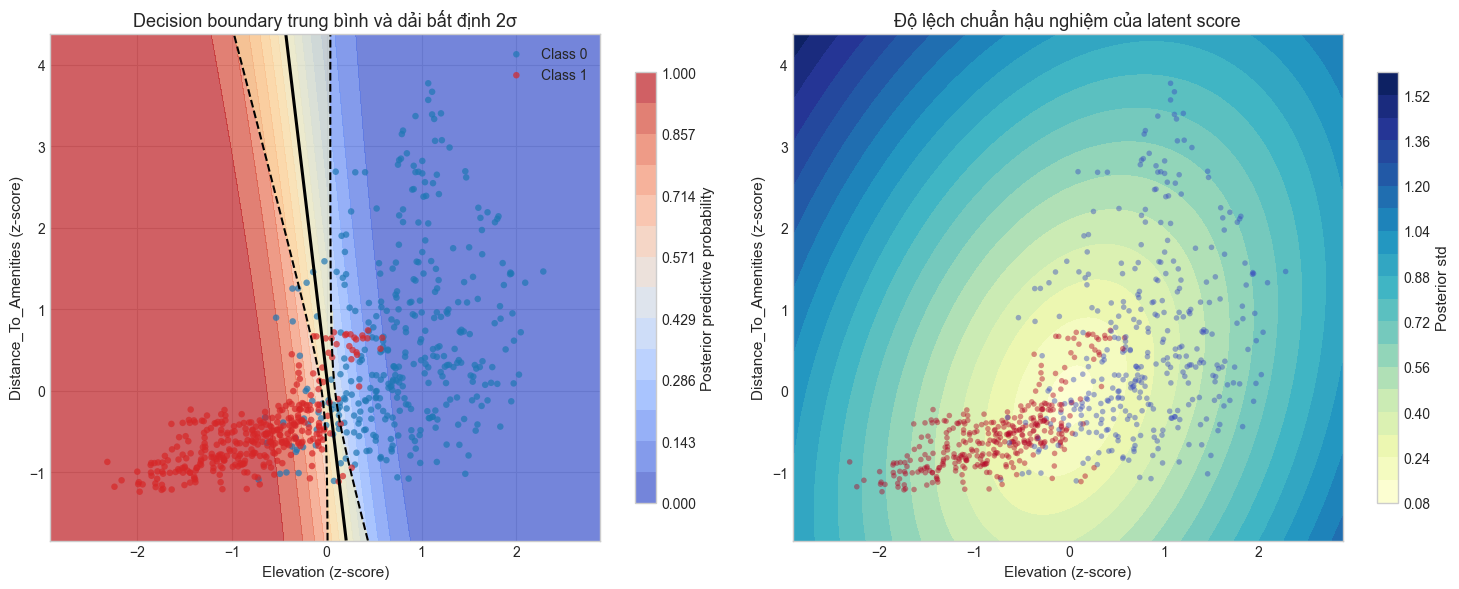

Bảng metric của Laplace approximation:


,Accuracy,Precision,Recall,F1,LogLoss,Brier,MeanLatentStd
MAP prediction,0.9111,0.9129,0.9089,0.9109,0.2088,0.0640,0.3613
Posterior predictive,0.9111,0.9129,0.9089,0.9109,0.2092,0.0641,0.3613



Validation với sklearn LogisticRegression:


,Accuracy,Precision,Recall,F1,LogLoss,Brier,MeanAbsProbDiff_vs_Custom
Custom MAP,0.9111,0.9129,0.9089,0.9109,0.2088,0.0640,0.0000
Sklearn Logistic,0.9089,0.9089,0.9089,0.9089,0.2089,0.0644,0.0103



Đường chéo posterior covariance:
[0.01974986 0.11489174 0.04387211]


In [3]:
class LaplaceLogisticRegression:
    def __init__(self, prior_precision=1.0, max_iter=80, tol=1e-8):
        self.prior_precision = prior_precision
        self.max_iter = max_iter
        self.tol = tol
        self.w_map_ = None
        self.hessian_ = None
        self.posterior_cov_ = None
        self.history_ = []

    def fit(self, X, y):
        X_bias = add_bias(X)
        y = np.asarray(y, dtype=float)
        n_features = X_bias.shape[1]
        w = np.zeros(n_features, dtype=float)
        reg_mask = np.eye(n_features, dtype=float)
        reg_mask[0, 0] = 0.0
        for _ in range(self.max_iter):
            probs = sigmoid(X_bias @ w)
            gradient = X_bias.T @ (probs - y) + self.prior_precision * (reg_mask @ w)
            R = np.clip(probs * (1.0 - probs), 1e-8, None)
            hessian = (X_bias.T * R) @ X_bias + self.prior_precision * reg_mask
            step = np.linalg.solve(hessian, gradient)
            updated_w = w - step
            neg_log_posterior = (
                -np.sum(
                    y * np.log(np.clip(probs, 1e-10, 1.0 - 1e-10))
                    + (1.0 - y) * np.log(np.clip(1.0 - probs, 1e-10, 1.0 - 1e-10))
                )
                + 0.5 * self.prior_precision * np.sum(updated_w[1:] ** 2)
            )
            self.history_.append(neg_log_posterior)
            if np.linalg.norm(step) < self.tol:
                w = updated_w
                break
            w = updated_w
        self.w_map_ = w
        self.hessian_ = hessian
        self.posterior_cov_ = np.linalg.pinv(hessian)
        return self

    def decision_function(self, X):
        return add_bias(X) @ self.w_map_

    def predict_proba(self, X):
        return sigmoid(self.decision_function(X))

    def posterior_predictive(self, X):
        X_bias = add_bias(X)
        latent_mean = X_bias @ self.w_map_
        latent_var = np.einsum("ij,jk,ik->i", X_bias, self.posterior_cov_, X_bias)
        latent_std = np.sqrt(np.clip(latent_var, 1e-12, None))
        kappa = 1.0 / np.sqrt(1.0 + (np.pi * latent_var) / 8.0)
        predictive_prob = sigmoid(kappa * latent_mean)
        return predictive_prob, latent_mean, latent_std


laplace_train_idx = stratified_index_sample(y_train_bin, total_size=700, seed=SEED)
X_train_laplace = X_train_bin[laplace_train_idx]
y_train_laplace = y_train_bin[laplace_train_idx]

laplace_model = LaplaceLogisticRegression(prior_precision=1.0, max_iter=80, tol=1e-8).fit(X_train_laplace, y_train_laplace)
map_probs = laplace_model.predict_proba(X_test_bin)
posterior_probs, latent_mean_test, latent_std_test = laplace_model.posterior_predictive(X_test_bin)

laplace_metrics = pd.DataFrame(
    {
        "MAP prediction": binary_metrics(y_test_bin, map_probs),
        "Posterior predictive": binary_metrics(y_test_bin, posterior_probs),
    }
).T
laplace_metrics["MeanLatentStd"] = [float(latent_std_test.mean()), float(latent_std_test.mean())]

sklearn_logistic_laplace = SklearnLogisticRegression(max_iter=2000, solver="lbfgs", C=100.0)
sklearn_logistic_laplace.fit(X_train_laplace, y_train_laplace)
sklearn_laplace_probs = sklearn_logistic_laplace.predict_proba(X_test_bin)[:, 1]
laplace_validation = pd.DataFrame(
    {
        "Custom MAP": binary_metrics(y_test_bin, map_probs),
        "Sklearn Logistic": binary_metrics(y_test_bin, sklearn_laplace_probs),
    }
).T
laplace_validation["MeanAbsProbDiff_vs_Custom"] = [0.0, np.mean(np.abs(sklearn_laplace_probs - map_probs))]

xx, yy = make_meshgrid(X_train_laplace, margin=0.6, n_points=240)
grid = np.column_stack([xx.ravel(), yy.ravel()])
grid_probs, grid_latent_mean, grid_latent_std = laplace_model.posterior_predictive(grid)
grid_probs = grid_probs.reshape(xx.shape)
grid_latent_mean = grid_latent_mean.reshape(xx.shape)
grid_latent_std = grid_latent_std.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fill = axes[0].contourf(xx, yy, grid_probs, levels=np.linspace(0.0, 1.0, 15), cmap="coolwarm", alpha=0.75)
uncertainty_mask = (np.abs(grid_latent_mean) <= 2.0 * grid_latent_std).astype(float)
axes[0].contourf(xx, yy, uncertainty_mask, levels=[0.5, 1.5], colors=["#fff2a8"], alpha=0.45)
axes[0].contour(xx, yy, grid_latent_mean, levels=[0.0], colors="black", linewidths=2.2)
axes[0].contour(xx, yy, grid_latent_mean - 2.0 * grid_latent_std, levels=[0.0], colors="black", linestyles="--")
axes[0].contour(xx, yy, grid_latent_mean + 2.0 * grid_latent_std, levels=[0.0], colors="black", linestyles="--")
axes[0].scatter(X_train_laplace[y_train_laplace == 0, 0], X_train_laplace[y_train_laplace == 0, 1], c="#1f77b4", s=22, alpha=0.70, label="Class 0", edgecolors="none")
axes[0].scatter(X_train_laplace[y_train_laplace == 1, 0], X_train_laplace[y_train_laplace == 1, 1], c="#d62728", s=22, alpha=0.70, label="Class 1", edgecolors="none")
axes[0].set_title("Decision boundary trung bình và dải bất định 2σ")
axes[0].set_xlabel(f"{selected_binary_features[0]} (z-score)")
axes[0].set_ylabel(f"{selected_binary_features[1]} (z-score)")
axes[0].legend()

std_plot = axes[1].contourf(xx, yy, grid_latent_std, levels=18, cmap="YlGnBu")
axes[1].scatter(X_train_laplace[:, 0], X_train_laplace[:, 1], c=y_train_laplace, cmap="coolwarm", s=16, alpha=0.45, edgecolors="none")
axes[1].set_title("Độ lệch chuẩn hậu nghiệm của latent score")
axes[1].set_xlabel(f"{selected_binary_features[0]} (z-score)")
axes[1].set_ylabel(f"{selected_binary_features[1]} (z-score)")

fig.colorbar(fill, ax=axes[0], shrink=0.85, label="Posterior predictive probability")
fig.colorbar(std_plot, ax=axes[1], shrink=0.85, label="Posterior std")
plt.tight_layout()
plt.show()

print("Bảng metric của Laplace approximation:")
display(laplace_metrics.round(4))
print("\nValidation với sklearn LogisticRegression:")
display(laplace_validation.round(4))
print("\nĐường chéo posterior covariance:")
print(np.diag(laplace_model.posterior_cov_))

laplace_summary = {
    "metrics": laplace_metrics,
    "validation": laplace_validation,
    "posterior_cov_diag": np.diag(laplace_model.posterior_cov_),
}

### Phân tích kết quả

Laplace Approximation bổ sung một thành phần mà Logistic Regression baseline không có: **uncertainty trên tham số và trên decision boundary**.

Các điểm cần chú ý khi đọc kết quả:

- **Đường liền** là decision boundary tại nghiệm MAP.
- **Hai đường đứt** biểu diễn xấp xỉ mức bất định $\pm 2\sigma$ quanh biên.
- **Vùng tô vàng** cho biết khu vực mà tín hiệu phân lớp không còn vượt trội rõ rệt so với độ lệch chuẩn hậu nghiệm.

Nếu so với Logistic Regression điểm-estimate trong notebook 03:

- dự đoán điểm (MAP) thường gần với logistic thông thường;
- posterior predictive thường **bớt cực đoan hơn** ở các vùng ít dữ liệu;
- phần quan trọng nhất không nằm ở việc tăng Accuracy, mà ở **khả năng diễn giải mức độ chắc chắn của biên quyết định**.

Trong thực hành, vùng bất định sẽ rộng hơn khi:

- số mẫu train ít,
- các lớp chồng lấn mạnh,
- hoặc prior quá yếu khiến posterior covariance lớn.

Vì thế, Laplace Approximation đặc biệt hữu ích khi ta cần không chỉ dự đoán nhãn, mà còn cần biết **mô hình đang tự tin đến đâu**.

## 3. Kernel Logistic Regression (Dual Form)

### Cơ sở lý thuyết

Với bài toán không tách tuyến tính, ta không dùng trực tiếp $\mathbf{w}^{\top}\mathbf{x}$ mà thay bằng biểu diễn đối ngẫu:

$$
f(\mathbf{x}) = \sum_{i=1}^{N}\alpha_i k(\mathbf{x}_i, \mathbf{x}) + b.
$$

Với **RBF kernel**:

$$
k(\mathbf{x}, \mathbf{x}')
=
\exp\left(-\gamma \|\mathbf{x} - \mathbf{x}'\|_2^2\right).
$$

Khi gom các kernel giữa mọi cặp điểm train, ta thu được **Gram matrix**:

$$
\mathbf{K}_{ij} = k(\mathbf{x}_i, \mathbf{x}_j).
$$

Hàm mục tiêu logistic trong dạng dual có regularization:

$$
\mathcal{J}(\boldsymbol{\alpha}, b)
=
-\frac{1}{N}\sum_{n=1}^{N}
\left[
y_n \log \sigma(f_n)
+
(1-y_n)\log(1-\sigma(f_n))
\right]
+
\frac{\lambda}{2}\boldsymbol{\alpha}^{\top}\mathbf{K}\boldsymbol{\alpha},
$$

với $f = \mathbf{K}\boldsymbol{\alpha} + b\mathbf{1}$.

Gradient tương ứng là:

$$
\nabla_{\boldsymbol{\alpha}}\mathcal{J}
=
\frac{1}{N}\mathbf{K}(\mathbf{p} - \mathbf{y})
+
\lambda \mathbf{K}\boldsymbol{\alpha},
\qquad
\frac{\partial \mathcal{J}}{\partial b}
=
\frac{1}{N}\mathbf{1}^{\top}(\mathbf{p} - \mathbf{y}).
$$

### Ý tưởng cài đặt

- Sinh dữ liệu **XOR-like** để đảm bảo bài toán **không tuyến tính**.
- Huấn luyện:
  - **Linear Logistic Regression** từ đầu như baseline tuyến tính,
  - **Kernel Logistic Regression (dual form)** với RBF kernel.
- So sánh:
  - Gram matrix,
  - decision boundary,
  - metric trên test set.

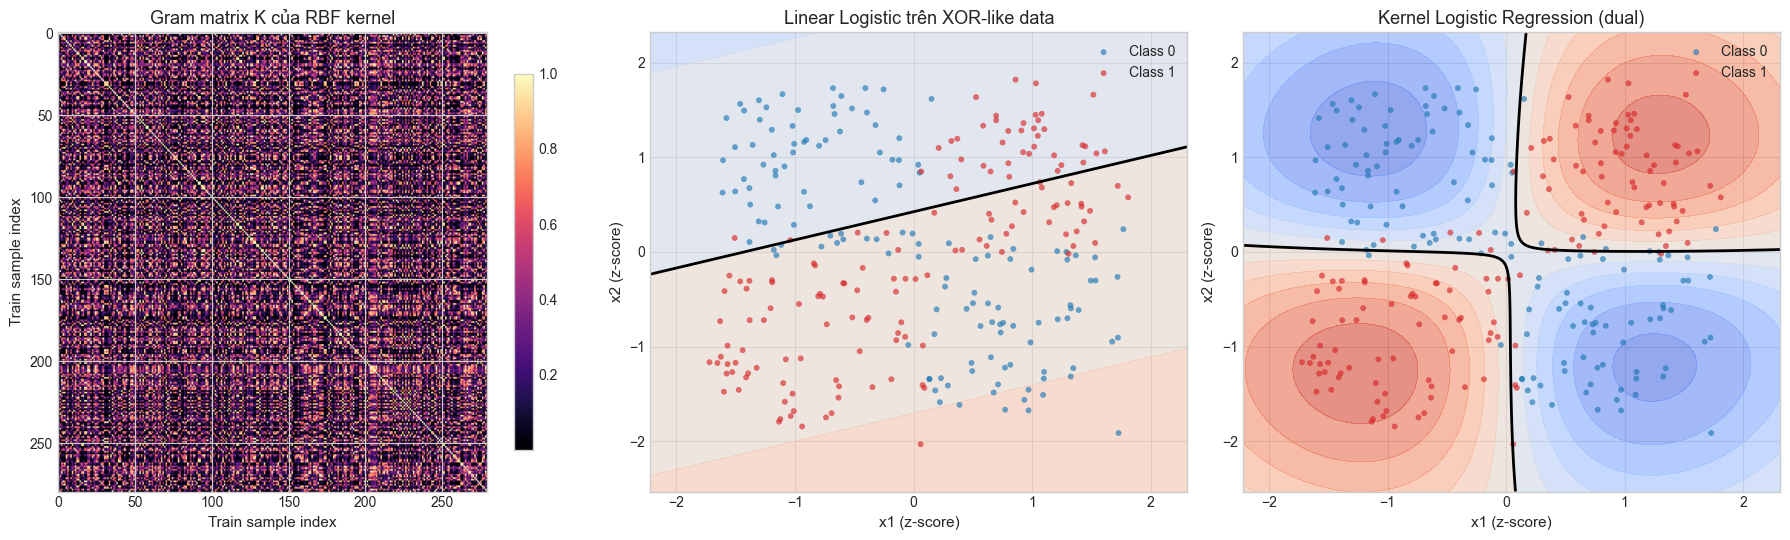

Bảng metric trên XOR-like test set:


,Accuracy,Precision,Recall,F1,LogLoss,Brier
Linear Logistic (scratch),0.5583,0.5541,0.6721,0.6074,0.6953,0.2511
Kernel Logistic (scratch),0.9417,0.9355,0.9508,0.9431,0.3424,0.0949



Validation bằng RBF-SVC (chỉ để sanity check hình dạng biên phi tuyến):


,Accuracy,Precision,Recall,F1,LogLoss,Brier
Kernel Logistic (scratch),0.9417,0.9355,0.9508,0.9431,0.3424,0.0949
RBF-SVC validation,0.9000,0.9016,0.9016,0.9016,0.1920,0.0633


In [4]:
class KernelLogisticRegressionDual:
    def __init__(self, gamma=0.5, learning_rate=0.08, max_iter=5000, lambda_reg=1e-2):
        self.gamma = gamma
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.lambda_reg = lambda_reg
        self.alpha_ = None
        self.bias_ = 0.0
        self.X_train_ = None
        self.gram_ = None
        self.history_ = []

    def _rbf_kernel(self, X_left, X_right):
        left_sq = np.sum(X_left ** 2, axis=1)[:, None]
        right_sq = np.sum(X_right ** 2, axis=1)[None, :]
        sq_dist = np.maximum(left_sq + right_sq - 2.0 * X_left @ X_right.T, 0.0)
        return np.exp(-self.gamma * sq_dist)

    def _loss(self, K, y):
        logits = K @ self.alpha_ + self.bias_
        probs = np.clip(sigmoid(logits), 1e-10, 1.0 - 1e-10)
        penalty = 0.5 * self.lambda_reg * (self.alpha_.T @ K @ self.alpha_)
        return -np.mean(y * np.log(probs) + (1.0 - y) * np.log(1.0 - probs)) + penalty

    def fit(self, X, y):
        self.X_train_ = np.asarray(X, dtype=float).copy()
        y = np.asarray(y, dtype=float)
        self.gram_ = self._rbf_kernel(self.X_train_, self.X_train_)
        n_samples = self.gram_.shape[0]
        self.alpha_ = np.zeros(n_samples, dtype=float)
        self.bias_ = 0.0
        for iteration in range(self.max_iter):
            logits = self.gram_ @ self.alpha_ + self.bias_
            probs = sigmoid(logits)
            grad_alpha = (self.gram_.T @ (probs - y)) / n_samples
            grad_alpha += self.lambda_reg * (self.gram_ @ self.alpha_)
            grad_bias = np.mean(probs - y)
            adaptive_step = self.learning_rate / (1.0 + 1e-3 * np.linalg.norm(grad_alpha))
            self.alpha_ -= adaptive_step * grad_alpha
            self.bias_ -= adaptive_step * grad_bias
            if iteration % 100 == 0:
                self.history_.append(self._loss(self.gram_, y))
        return self

    def decision_function(self, X):
        K_cross = self._rbf_kernel(np.asarray(X, dtype=float), self.X_train_)
        return K_cross @ self.alpha_ + self.bias_

    def predict_proba(self, X):
        return sigmoid(self.decision_function(X))

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


X_xor, y_xor = make_xor_dataset(n_samples=400, noise=0.20, seed=SEED)
X_train_xor, X_test_xor, y_train_xor, y_test_xor = train_test_split(
    X_xor, y_xor, test_size=0.30, stratify=y_xor, random_state=SEED
)
xor_scaler = StandardScaler().fit(X_train_xor)
X_train_xor = xor_scaler.transform(X_train_xor)
X_test_xor = xor_scaler.transform(X_test_xor)

linear_xor_model = BinaryLogisticGD(learning_rate=0.20, max_iter=3000, lambda_reg=1e-2).fit(X_train_xor, y_train_xor)
kernel_xor_model = KernelLogisticRegressionDual(gamma=0.50, learning_rate=0.08, max_iter=5000, lambda_reg=1e-2).fit(X_train_xor, y_train_xor)

linear_xor_probs = linear_xor_model.predict_proba(X_test_xor)
kernel_xor_probs = kernel_xor_model.predict_proba(X_test_xor)

xor_metrics = pd.DataFrame(
    {
        "Linear Logistic (scratch)": binary_metrics(y_test_xor, linear_xor_probs),
        "Kernel Logistic (scratch)": binary_metrics(y_test_xor, kernel_xor_probs),
    }
).T

svc_validation = SVC(kernel="rbf", gamma=0.50, C=10.0, probability=True, random_state=SEED)
svc_validation.fit(X_train_xor, y_train_xor)
svc_probs = svc_validation.predict_proba(X_test_xor)[:, 1]
xor_validation = pd.DataFrame(
    {
        "Kernel Logistic (scratch)": binary_metrics(y_test_xor, kernel_xor_probs),
        "RBF-SVC validation": binary_metrics(y_test_xor, svc_probs),
    }
).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
gram_im = axes[0].imshow(kernel_xor_model.gram_, cmap="magma", aspect="auto")
axes[0].set_title("Gram matrix K của RBF kernel")
axes[0].set_xlabel("Train sample index")
axes[0].set_ylabel("Train sample index")
fig.colorbar(gram_im, ax=axes[0], shrink=0.82)
plot_binary_boundary(axes[1], linear_xor_model, X_train_xor, y_train_xor, ["x1", "x2"], "Linear Logistic trên XOR-like data")
plot_binary_boundary(axes[2], kernel_xor_model, X_train_xor, y_train_xor, ["x1", "x2"], "Kernel Logistic Regression (dual)")
plt.tight_layout()
plt.show()

print("Bảng metric trên XOR-like test set:")
display(xor_metrics.round(4))
print("\nValidation bằng RBF-SVC (chỉ để sanity check hình dạng biên phi tuyến):")
display(xor_validation.round(4))

kernel_logistic_summary = {
    "metrics": xor_metrics,
    "validation": xor_validation,
    "gram_shape": kernel_xor_model.gram_.shape,
}

### Phân tích kết quả

Đây là section cho thấy lợi ích rõ nhất của kernel hóa:

- **Linear Logistic Regression** chỉ tạo được một đường thẳng, nên trên dữ liệu XOR-like gần như không thể tách đúng bốn vùng tín hiệu.
- **Kernel Logistic Regression** chuyển bài toán sang không gian đặc trưng ngầm có độ phức tạp cao hơn, nhờ đó decision boundary có thể uốn cong theo cấu trúc checkerboard.
- **Gram matrix** trực quan hóa việc mô hình không còn làm việc bằng từng hệ số tuyến tính độc lập, mà bằng độ tương tự giữa các điểm train.

So với baseline Logistic Regression ở notebook 03, khác biệt ở đây không phải là cách tối ưu mà là **không gian giả thuyết**:

- logistic tuyến tính: giả thuyết là một siêu phẳng,
- kernel logistic: giả thuyết là tổng có trọng số của các kernel centered tại từng điểm train.

Vì vậy, nếu metric của Kernel Logistic vượt xa linear logistic thì đó là bằng chứng trực tiếp rằng **dữ liệu không tuyến tính** và biểu diễn dual với RBF kernel là phù hợp hơn nhiều cho loại cấu trúc này.

## 4. Gaussian Naive Bayes vs LDA

### Cơ sở lý thuyết

Cả **Gaussian Naive Bayes (GNB)** và **Linear Discriminant Analysis (LDA)** đều là mô hình sinh (generative models), nhưng khác nhau ở giả thiết xác suất.

#### Gaussian Naive Bayes

GNB giả sử các đặc trưng độc lập có điều kiện theo lớp:

$$
p(\mathbf{x}\mid y=k)
=
\prod_{j=1}^{D}
\mathcal{N}(x_j \mid \mu_{kj}, \sigma_{kj}^2).
$$

#### Linear Discriminant Analysis

LDA cũng giả sử phân phối Gaussian theo lớp, nhưng thay vì độc lập có điều kiện, LDA giữ **ma trận hiệp phương sai dùng chung**:

$$
p(\mathbf{x}\mid y=k) = \mathcal{N}(\mathbf{x}\mid \boldsymbol{\mu}_k, \mathbf{\Sigma}).
$$

Khi đó discriminant function là tuyến tính:

$$
\delta_k(\mathbf{x})
=
\mathbf{x}^{\top}\mathbf{\Sigma}^{-1}\boldsymbol{\mu}_k
-
\frac{1}{2}\boldsymbol{\mu}_k^{\top}\mathbf{\Sigma}^{-1}\boldsymbol{\mu}_k
+
\log \pi_k.
$$

#### Hệ quả về bias-variance trade-off

- **GNB** có bias mạnh hơn vì bỏ qua tương quan giữa các đặc trưng, nhưng variance thấp hơn vì số tham số ít.
- **LDA** tận dụng tương quan đặc trưng tốt hơn, nhưng phải ước lượng covariance dùng chung nên nhạy cảm hơn khi dữ liệu ít hoặc covariance thật giữa các lớp khác nhau rõ rệt.

### Ý tưởng cài đặt

- Dùng **Covertype đa lớp** với nhóm đặc trưng Gaussian-friendly: 10 biến continuous gốc và 2 biến engineered.
- Cài đặt cả **GNB** và **LDA** hoàn toàn bằng `numpy`.
- So sánh theo hai góc:
  - hiệu năng đa lớp tổng quát,
  - một **pairwise diagnostic** để chỉ ra khi nào GNB có thể vượt LDA.

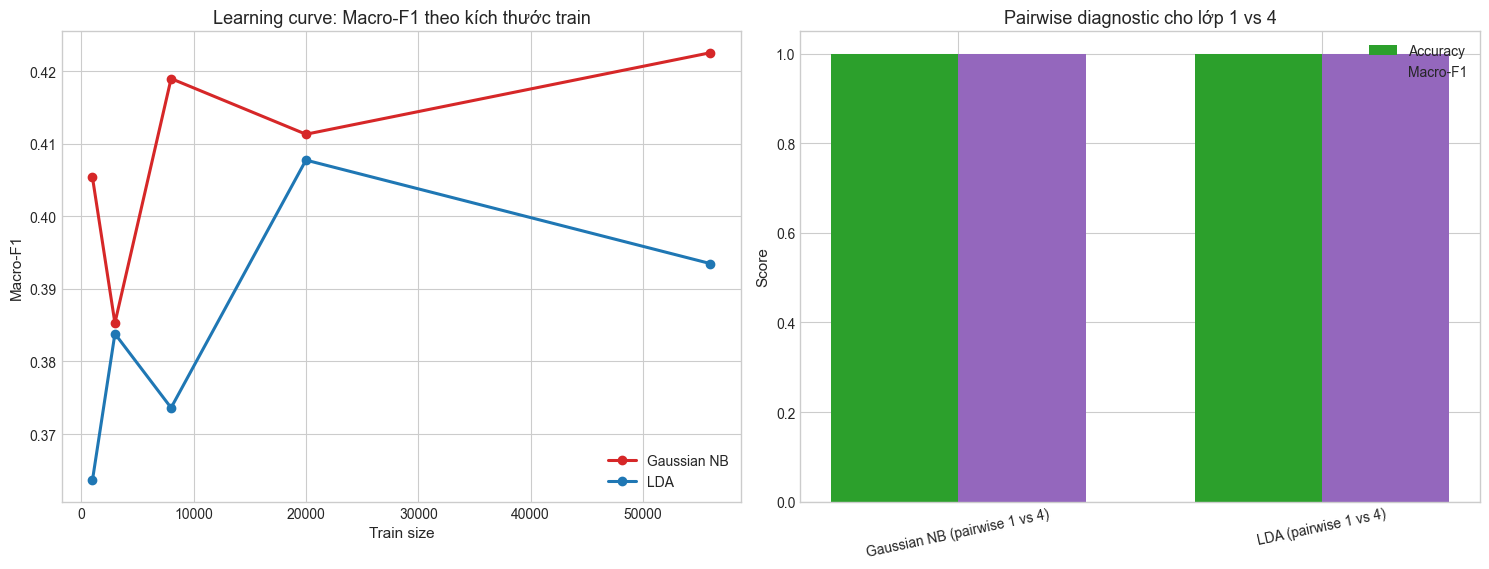

Kết quả đa lớp trên Covertype (12 Gaussian-friendly features):


,Accuracy,MacroPrecision,MacroRecall,MacroF1
Gaussian NB (scratch),0.6114,0.3932,0.4716,0.4226
LDA (scratch),0.6925,0.5005,0.3777,0.3935



Validation giữa scratch và sklearn:


,Accuracy,MacroPrecision,MacroRecall,MacroF1
Gaussian NB (scratch),0.6114,0.3932,0.4716,0.4226
Gaussian NB (sklearn),0.6114,0.3932,0.4716,0.4226
LDA (scratch),0.6925,0.5005,0.3777,0.3935
LDA (sklearn),0.6929,0.5433,0.3841,0.4036



Pairwise diagnostic (lớp 1 vs 4):


,Accuracy,MacroPrecision,MacroRecall,MacroF1
Gaussian NB (pairwise 1 vs 4),0.9992,0.9992,0.9992,0.9992
LDA (pairwise 1 vs 4),0.9983,0.9983,0.9983,0.9983



Chỉ số chẩn đoán cấu trúc dữ liệu:
Mean absolute off-diagonal correlation: 0.2059
Variance gap score between class 1 and 4: 1.0118


In [5]:
class GaussianNaiveBayesScratch:
    def __init__(self, var_smoothing=1e-6):
        self.var_smoothing = var_smoothing
        self.classes_ = None
        self.priors_ = None
        self.means_ = None
        self.vars_ = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_features = X.shape[1]
        self.priors_ = np.zeros(n_classes, dtype=float)
        self.means_ = np.zeros((n_classes, n_features), dtype=float)
        self.vars_ = np.zeros((n_classes, n_features), dtype=float)
        for idx, class_id in enumerate(self.classes_):
            X_class = X[y == class_id]
            self.priors_[idx] = len(X_class) / len(X)
            self.means_[idx] = X_class.mean(axis=0)
            self.vars_[idx] = X_class.var(axis=0) + self.var_smoothing
        return self

    def joint_log_likelihood(self, X):
        X = np.asarray(X, dtype=float)
        all_scores = []
        for idx, class_id in enumerate(self.classes_):
            mean_vec = self.means_[idx]
            var_vec = self.vars_[idx]
            log_det = np.sum(np.log(2.0 * np.pi * var_vec))
            quadratic = np.sum(((X - mean_vec) ** 2) / var_vec, axis=1)
            score = -0.5 * (log_det + quadratic) + np.log(self.priors_[idx])
            all_scores.append(score)
        return np.column_stack(all_scores)

    def predict_proba(self, X):
        joint = self.joint_log_likelihood(X)
        return np.exp(joint - logsumexp(joint, axis=1, keepdims=True))

    def predict(self, X):
        joint = self.joint_log_likelihood(X)
        return self.classes_[np.argmax(joint, axis=1)]


class LDAScratch:
    def __init__(self, shrinkage=1e-4):
        self.shrinkage = shrinkage
        self.classes_ = None
        self.priors_ = None
        self.means_ = None
        self.covariance_ = None
        self.covariance_inv_ = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_features = X.shape[1]
        n_classes = len(self.classes_)
        self.priors_ = np.zeros(n_classes, dtype=float)
        self.means_ = np.zeros((n_classes, n_features), dtype=float)
        pooled = np.zeros((n_features, n_features), dtype=float)
        for idx, class_id in enumerate(self.classes_):
            X_class = X[y == class_id]
            self.priors_[idx] = len(X_class) / len(X)
            mean_vec = X_class.mean(axis=0)
            self.means_[idx] = mean_vec
            centered = X_class - mean_vec
            pooled += centered.T @ centered
        pooled /= max(len(X) - n_classes, 1)
        pooled += self.shrinkage * np.eye(n_features)
        self.covariance_ = pooled
        self.covariance_inv_ = np.linalg.pinv(pooled)
        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=float)
        scores = []
        for idx, class_id in enumerate(self.classes_):
            mean_vec = self.means_[idx]
            linear_part = X @ self.covariance_inv_ @ mean_vec
            intercept = -0.5 * mean_vec.T @ self.covariance_inv_ @ mean_vec + np.log(self.priors_[idx])
            scores.append(linear_part + intercept)
        return np.column_stack(scores)

    def predict_proba(self, X):
        scores = self.decision_function(X)
        return np.exp(scores - logsumexp(scores, axis=1, keepdims=True))

    def predict(self, X):
        scores = self.decision_function(X)
        return self.classes_[np.argmax(scores, axis=1)]


covtype_multi_df = stratified_dataframe_sample(
    df_covtype[gaussian_feature_cols + ["Cover_Type"]],
    target_col="Cover_Type",
    total_size=70000,
    seed=SEED,
)
X_multi = covtype_multi_df[gaussian_feature_cols].to_numpy()
y_multi = covtype_multi_df["Cover_Type"].to_numpy()
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.20, stratify=y_multi, random_state=SEED
)
X_train_multi, X_test_multi, multi_mean, multi_std = standardize_train_test(X_train_multi, X_test_multi)

gnb_model = GaussianNaiveBayesScratch(var_smoothing=1e-4).fit(X_train_multi, y_train_multi)
lda_model = LDAScratch(shrinkage=1e-3).fit(X_train_multi, y_train_multi)
gnb_pred = gnb_model.predict(X_test_multi)
lda_pred = lda_model.predict(X_test_multi)

multiclass_results = pd.DataFrame(
    {
        "Gaussian NB (scratch)": multiclass_metrics(y_test_multi, gnb_pred),
        "LDA (scratch)": multiclass_metrics(y_test_multi, lda_pred),
    }
).T

sklearn_gnb = SklearnGaussianNB(var_smoothing=1e-4)
sklearn_lda = SklearnLDA(solver="svd")
sklearn_gnb.fit(X_train_multi, y_train_multi)
sklearn_lda.fit(X_train_multi, y_train_multi)
validation_gnb_lda = pd.DataFrame(
    {
        "Gaussian NB (scratch)": multiclass_metrics(y_test_multi, gnb_pred),
        "Gaussian NB (sklearn)": multiclass_metrics(y_test_multi, sklearn_gnb.predict(X_test_multi)),
        "LDA (scratch)": multiclass_metrics(y_test_multi, lda_pred),
        "LDA (sklearn)": multiclass_metrics(y_test_multi, sklearn_lda.predict(X_test_multi)),
    }
).T

learning_curve_sizes = [1000, 3000, 8000, 20000, len(X_train_multi)]
learning_curve_rows = []
for train_size in learning_curve_sizes:
    sampled_idx = stratified_index_sample(y_train_multi, total_size=train_size, seed=SEED + train_size)
    X_subset = X_train_multi[sampled_idx]
    y_subset = y_train_multi[sampled_idx]
    gnb_subset = GaussianNaiveBayesScratch(var_smoothing=1e-4).fit(X_subset, y_subset)
    lda_subset = LDAScratch(shrinkage=1e-3).fit(X_subset, y_subset)
    gnb_metrics = multiclass_metrics(y_test_multi, gnb_subset.predict(X_test_multi))
    lda_metrics = multiclass_metrics(y_test_multi, lda_subset.predict(X_test_multi))
    learning_curve_rows.append({"TrainSize": train_size, "Model": "Gaussian NB", "Accuracy": gnb_metrics["Accuracy"], "MacroF1": gnb_metrics["MacroF1"]})
    learning_curve_rows.append({"TrainSize": train_size, "Model": "LDA", "Accuracy": lda_metrics["Accuracy"], "MacroF1": lda_metrics["MacroF1"]})
learning_curve_df = pd.DataFrame(learning_curve_rows)

pairwise_df = balanced_pair_sample(df_covtype, class_pair=(1, 4), n_per_class=2000, seed=SEED)
X_pairwise = pairwise_df[gaussian_feature_cols].to_numpy()
y_pairwise = pairwise_df["Cover_Type"].to_numpy()
X_train_pairwise, X_test_pairwise, y_train_pairwise, y_test_pairwise = train_test_split(
    X_pairwise, y_pairwise, test_size=0.30, stratify=y_pairwise, random_state=SEED
)
X_train_pairwise, X_test_pairwise, pair_mean, pair_std = standardize_train_test(X_train_pairwise, X_test_pairwise)
gnb_pairwise = GaussianNaiveBayesScratch(var_smoothing=1e-4).fit(X_train_pairwise, y_train_pairwise)
lda_pairwise = LDAScratch(shrinkage=1e-3).fit(X_train_pairwise, y_train_pairwise)
gnb_pairwise_pred = gnb_pairwise.predict(X_test_pairwise)
lda_pairwise_pred = lda_pairwise.predict(X_test_pairwise)

pairwise_results = pd.DataFrame(
    {
        "Gaussian NB (pairwise 1 vs 4)": multiclass_metrics(y_test_pairwise, gnb_pairwise_pred),
        "LDA (pairwise 1 vs 4)": multiclass_metrics(y_test_pairwise, lda_pairwise_pred),
    }
).T

class2_var = X_train_pairwise[y_train_pairwise == 1].var(axis=0) + 1e-10
class5_var = X_train_pairwise[y_train_pairwise == 4].var(axis=0) + 1e-10
variance_gap_score = float(np.mean(np.abs(np.log(class2_var / class5_var))))

corr_matrix = np.corrcoef(X_train_multi, rowvar=False)
off_diagonal_mask = ~np.eye(corr_matrix.shape[0], dtype=bool)
mean_abs_offdiag_corr = float(np.mean(np.abs(corr_matrix[off_diagonal_mask])))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
for model_name, color in [("Gaussian NB", "#d62728"), ("LDA", "#1f77b4")]:
    subset = learning_curve_df[learning_curve_df["Model"] == model_name]
    axes[0].plot(subset["TrainSize"], subset["MacroF1"], marker="o", linewidth=2.2, label=model_name, color=color)
axes[0].set_title("Learning curve: Macro-F1 theo kích thước train")
axes[0].set_xlabel("Train size")
axes[0].set_ylabel("Macro-F1")
axes[0].legend()

pair_plot_df = pairwise_results[["Accuracy", "MacroF1"]].copy()
x_pos = np.arange(len(pair_plot_df.index))
width = 0.35
axes[1].bar(x_pos - width / 2, pair_plot_df["Accuracy"], width=width, label="Accuracy", color="#2ca02c")
axes[1].bar(x_pos + width / 2, pair_plot_df["MacroF1"], width=width, label="Macro-F1", color="#9467bd")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(pair_plot_df.index, rotation=12)
axes[1].set_ylim(0.0, 1.05)
axes[1].set_title("Pairwise diagnostic cho lớp 1 vs 4")
axes[1].set_ylabel("Score")
axes[1].legend()
plt.tight_layout()
plt.show()

print("Kết quả đa lớp trên Covertype (12 Gaussian-friendly features):")
display(multiclass_results.round(4))
print("\nValidation giữa scratch và sklearn:")
display(validation_gnb_lda.round(4))
print("\nPairwise diagnostic (lớp 1 vs 4):")
display(pairwise_results.round(4))
print("\nChỉ số chẩn đoán cấu trúc dữ liệu:")
print(f"Mean absolute off-diagonal correlation: {mean_abs_offdiag_corr:.4f}")
print(f"Variance gap score between class 1 and 4: {variance_gap_score:.4f}")

gnb_lda_summary = {
    "multiclass_results": multiclass_results,
    "validation": validation_gnb_lda,
    "pairwise_results": pairwise_results,
    "learning_curve": learning_curve_df,
    "mean_abs_offdiag_corr": mean_abs_offdiag_corr,
    "variance_gap_score": variance_gap_score,
}

### Phân tích kết quả

Section này cần đọc theo hai tầng:

#### 1. Bài toán đa lớp tổng quát trên Covertype

Nếu **LDA** tốt hơn **GNB** trên bảng đa lớp chính, điều đó cho thấy các đặc trưng địa hình vẫn mang **tương quan hữu ích** và giả thiết covariance dùng chung không quá tệ. Chỉ số `mean_abs_offdiag_corr` giúp kiểm chứng điều này: khi tương quan ngoài đường chéo không nhỏ, giả thiết độc lập có điều kiện của GNB trở nên khá mạnh tay.

#### 2. Khi nào GNB có thể vượt LDA?

Pairwise diagnostic lớp **1 vs 4** được đưa vào đúng để trả lời câu hỏi này. Nếu ở cặp này GNB nhỉnh hơn hoặc ít nhất bám sát hơn LDA, thì nguyên nhân thường là:

- covariance thật giữa hai lớp **khác nhau đáng kể**,
- hoặc chênh lệch variance theo từng đặc trưng lớn, thể hiện qua `variance_gap_score`,
- trong khi giả thiết covariance dùng chung của LDA trở thành ràng buộc quá cứng.

#### Kết luận thực nghiệm

- **LDA** thường thắng khi có đủ dữ liệu và khi việc mô hình hóa tương quan đặc trưng mang lại lợi ích rõ.
- **GNB** có thể thắng trong những bài toán con mà:
  - số mẫu nhỏ hơn,
  - covariance giữa các lớp khác nhau mạnh,
  - hoặc ta ưu tiên mô hình đơn giản, ít tham số hơn.

So với baseline LDA ở notebook 03, phần bonus này mở rộng thêm góc nhìn **bias-variance trade-off giữa diagonal covariance và shared full covariance**, thay vì chỉ dừng ở so sánh LDA/QDA.

## 5. VC Dimension của Linear Classifiers trong $\mathbb{R}^D$

### Cơ sở lý thuyết

Xét họ bộ phân lớp tuyến tính affine:

$$
h(\mathbf{x}) = \operatorname{sign}(\mathbf{w}^{\top}\mathbf{x} + b),
\qquad
\mathbf{x}\in \mathbb{R}^{D}.
$$

**VC dimension** của họ giả thuyết này là:

$$
\mathrm{VCdim} = D + 1.
$$

Nếu ta chỉ xét siêu phẳng đi qua gốc ($b = 0$), khi đó:

$$
\mathrm{VCdim} = D.
$$

### Vì sao lại là $D+1$?

Trực giác là một siêu phẳng affine trong $\mathbb{R}^{D}$ có thể điều khiển đủ bậc tự do để shatter được tối đa $D+1$ điểm ở vị trí tổng quát, nhưng không thể shatter mọi cấu hình của $D+2$ điểm. Đây là giới hạn năng lực phân tách của một mô hình tuyến tính, hoàn toàn không phụ thuộc việc ta dùng:

- perceptron,
- logistic regression,
- hay probit model,

miễn là không gian giả thuyết cuối cùng vẫn là **siêu phẳng tuyến tính** trong $\mathbb{R}^{D}$.

### Liên hệ với generalization

Một dạng trực giác của upper bound là:

$$
R(h)
\le
\hat{R}(h)
+
\mathcal{O}
\left(
\sqrt{
\frac{\mathrm{VCdim}\log n + \log(1/\delta)}{n}
}
\right),
$$

trong đó:

- $R(h)$ là true risk,
- $\hat{R}(h)$ là empirical risk,
- $n$ là số mẫu,
- $\delta$ là mức tin cậy.

Khi $D$ tăng mà $n$ không tăng tương ứng, bound khái quát hóa sẽ lỏng hơn. Đây là lý do vì sao các mô hình tuyến tính trong không gian rất nhiều chiều có thể cần:

- regularization,
- feature selection,
- hoặc dimensionality reduction.

### Liên hệ với Structural Risk Minimization

**Structural Risk Minimization (SRM)** không chỉ tối thiểu hóa lỗi huấn luyện mà còn kiểm soát độ phức tạp của mô hình. Trong ngữ cảnh notebook này:

- **Logistic Regression** và **Probit** có cùng lớp giả thuyết tuyến tính nên về bản chất có VC dimension tương đương.
- **Kernel Logistic Regression với RBF kernel** tương ứng với một không gian đặc trưng rất giàu, thậm chí có thể xem như vô hạn chiều; do đó regularization đóng vai trò quyết định để kiểm soát năng lực mô hình.
- **LDA** cũng tạo decision boundary tuyến tính trong không gian đầu vào, nhưng do là mô hình sinh nên cách kiểm soát năng lực đi qua giả thiết phân phối thay vì chỉ qua biên dạng của boundary.

### Phân tích ý nghĩa thực hành

VC dimension giúp giải thích vì sao trong project phân loại này ta luôn phải cân bằng giữa **độ khớp dữ liệu** và **độ phức tạp mô hình**:

- Khi dùng mô hình tuyến tính trên số chiều vừa phải, khả năng khái quát hóa thường tốt hơn và dễ diễn giải hơn.
- Khi chuyển sang kernel hóa, năng lực mô hình tăng mạnh; nếu không regularize tốt thì rất dễ overfit dù train error rất thấp.
- Vì vậy, bonus part không chỉ là “thêm mô hình mạnh hơn”, mà còn là minh họa trực tiếp cho triết lý SRM:
  - tăng năng lực mô hình khi cần,
  - nhưng luôn kèm cơ chế kiểm soát độ phức tạp.

Đây cũng là cầu nối tự nhiên giữa các phần trong notebook:

- **Probit / Logistic / Laplace**: cùng họ tuyến tính nên khác nhau chủ yếu ở cách mô hình hóa xác suất và uncertainty;
- **Kernel Logistic**: thay đổi không gian giả thuyết, từ đó thay đổi hẳn capacity;
- **GNB vs LDA**: cho thấy không chỉ boundary, mà cả giả thiết xác suất cũng là một dạng kiểm soát độ phức tạp mô hình.